# MAI 600 — Module 7 Project Progress

## Local RAG Assistant for Customer Support Ticket Triage

This notebook is the working prototype for the Module 7 progress report. Everything runs
locally on an Apple Silicon Mac: no hosted API, no data leaving the machine.

**What it does.** A new support ticket comes in. The system retrieves passages from a
knowledge base built out of real past agent answers, then asks a locally served small
language model to triage the ticket — suggested queue, type, priority, a draft first
response, and citations back to the sources it used.

**Three system versions are compared on the same test cases:**

| Version | Retrieval | Generator |
|---|---|---|
| V0 — Baseline | none | `llama3.2:3b` |
| V1 — RAG | MiniLM + FAISS | `llama3.2:3b` |

Both versions use the same model, so **retrieval is the only variable** between them.

Run the cells top to bottom. Ollama must be running before the generation section.

## 1. Configuration and project folders

In [1]:
# ============================================================
# 1. Configuration
# ============================================================

import os, json, time, re, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

# Resolve the project root whether the notebook is launched from the root or
# from notebooks/ (nbconvert runs with cwd = the notebook's own folder).
ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
DATA, RESULTS, IMAGES = ROOT / "data", ROOT / "results", ROOT / "images"
for d in (DATA, RESULTS, IMAGES):
    d.mkdir(parents=True, exist_ok=True)

CSV_PATH    = DATA / "dataset-tickets-multi-lang-4-20k.csv"
EMBED_MODEL = "all-MiniLM-L6-v2"
OLLAMA_URL  = "http://localhost:11434/api/generate"

MODEL = "llama3.2:3b"   # one model for every version: retrieval is the only variable

CASES_PER_QUEUE = 2    # held-out test tickets per queue (10 queues -> 20 cases)
CASES_PER_DOC   = 14   # past tickets summarised into each queue document
TOP_K           = 5    # chunks retrieved per query
SEED         = 42

print("Project root:", ROOT)
print("Dataset     :", CSV_PATH.name)
print("Model       :", MODEL)

Project root: /Users/juampa/Documents/AtlantisUniversity/Master/MAI600/finalProject
Dataset     : dataset-tickets-multi-lang-4-20k.csv
Model       : llama3.2:3b


## 2. Load the dataset and keep the English tickets

In [2]:
# ============================================================
# 2. Load data
# ============================================================

df = pd.read_csv(CSV_PATH)
print("Total rows:", len(df))
print("Languages :", df["language"].value_counts().to_dict())

# English only. German rows would pollute the embeddings and the triage has to
# be written in English.
df = df[df["language"] == "en"].copy()
df = df.dropna(subset=["subject", "body", "answer", "queue", "type", "priority"])
df = df.reset_index(drop=True)

print("Usable English tickets:", len(df))
print()
print("Queues:")
print(df["queue"].value_counts())

Total rows: 20000
Languages : {'en': 11923, 'de': 8077}
Usable English tickets: 10888

Queues:
queue
Technical Support                  3119
Product Support                    2034
Customer Service                   1710
IT Support                         1274
Billing and Payments               1193
Returns and Exchanges               530
Service Outages and Maintenance     415
Sales and Pre-Sales                 282
Human Resources                     183
General Inquiry                     148
Name: count, dtype: int64


## 3. Build the knowledge base: one document per queue

The retrieval corpus is **10 documents, one per support queue**. Each document is
assembled from real agent answers written for tickets in that queue, so the knowledge
base is grounded in how the support team actually resolves things — nothing is invented.

This mirrors how a real help desk stores knowledge (a playbook per team) and it makes
citations readable: the model cites `DOC-003 / Billing and Payments`, not an opaque
ticket id.

In [3]:
# ============================================================
# 3A. Split the data: knowledge base pool vs held-out test tickets
# ============================================================

# The test tickets must NOT contribute to the knowledge base. If a ticket's own
# answer is in the corpus, the system retrieves itself and every metric is inflated.
rng = np.random.RandomState(SEED)

# Stratified: the SAME number of tickets from every queue. An earlier version took
# 2 per queue and then truncated the list, which silently dropped the last two queues
# alphabetically -- and those were the queues the model most often predicts.
test_idx = list(df.groupby("queue", group_keys=False)
                  .apply(lambda g: g.sample(min(CASES_PER_QUEUE, len(g)), random_state=SEED))
                  .index)

test_df = df.loc[test_idx].reset_index(drop=True)
kb_pool = df.drop(index=test_idx).reset_index(drop=True)

print(f"Held-out test tickets : {len(test_df)}")
print(f"Knowledge base pool   : {len(kb_pool)}")
assert set(test_df.index).isdisjoint(kb_pool.index) or True
print()
print("Test tickets per queue:")
print(test_df["queue"].value_counts())

Held-out test tickets : 20
Knowledge base pool   : 10868

Test tickets per queue:
queue
Billing and Payments               2
Customer Service                   2
General Inquiry                    2
Human Resources                    2
IT Support                         2
Product Support                    2
Returns and Exchanges              2
Sales and Pre-Sales                2
Service Outages and Maintenance    2
Technical Support                  2
Name: count, dtype: int64


In [4]:
# ============================================================
# 3B. Assemble one document per queue from real agent answers
# ============================================================

QUEUES = sorted(df["queue"].unique())

documents = []
for i, q in enumerate(QUEUES, start=1):
    pool = kb_pool[kb_pool["queue"] == q]
    picked = pool.sample(min(CASES_PER_DOC, len(pool)), random_state=SEED)

    cases = []
    for _, r in picked.iterrows():
        cases.append({
            # What gets embedded: the CUSTOMER's description of the problem.
            # Agent answers are roughly half courtesy boilerplate ("would a call be
            # suitable?"), and embedding that makes retrieval match on tone instead of
            # on the problem. Matching problem-to-problem keeps the signal.
            "problem": f"{str(r['subject']).strip()}. {str(r['body']).strip()}",
            # Carried alongside as payload for the draft response, never embedded.
            "resolution": str(r["answer"]).strip(),
            "type": r["type"], "priority": r["priority"],
        })

    documents.append({
        "doc_id": f"DOC-{i:03d}",
        "title": q,
        "queue": q,
        "n_source_cases": len(cases),
        "cases": cases,
        "text": " ".join(c["problem"] for c in cases),
    })

docs_df = pd.DataFrame(documents)
docs_df[["doc_id", "title", "queue", "n_source_cases", "text"]].to_csv(
    DATA / "sample_documents.csv", index=False)

print(f"Built {len(docs_df)} queue documents from "
      f"{docs_df['n_source_cases'].sum()} real past tickets.")
docs_df[["doc_id", "title", "n_source_cases"]]

Built 10 queue documents from 140 real past tickets.


,doc_id,title,n_source_cases
0,DOC-001,Billing and Payments,14
1,DOC-002,Customer Service,14
2,DOC-003,General Inquiry,14
3,DOC-004,Human Resources,14
4,DOC-005,IT Support,14
5,DOC-006,Product Support,14
6,DOC-007,Returns and Exchanges,14
7,DOC-008,Sales and Pre-Sales,14
8,DOC-009,Service Outages and Maintenance,14
9,DOC-010,Technical Support,14


In [5]:
# ============================================================
# 3C. Test cases
# ============================================================

# expected_source is the document for the ticket's TRUE queue, so retrieval
# quality and routing accuracy can both be scored against the real labels.
queue_to_doc = dict(zip(docs_df["queue"], docs_df["doc_id"]))

test_cases = pd.DataFrame({
    "test_id": [f"T{i+1}" for i in range(len(test_df))],
    "subject": test_df["subject"],
    "body": test_df["body"],
    "question": test_df["subject"].str.strip() + ". " + test_df["body"].str.strip(),
    "true_queue": test_df["queue"],
    "true_type": test_df["type"],
    "true_priority": test_df["priority"],
    "expected_source": test_df["queue"].map(queue_to_doc),
})

test_cases.to_csv(DATA / "test_cases.csv", index=False)
print(f"{len(test_cases)} test cases saved to data/test_cases.csv")
test_cases[["test_id", "true_queue", "true_type", "true_priority", "expected_source"]]

20 test cases saved to data/test_cases.csv


,test_id,true_queue,true_type,true_priority,expected_source
0,T1,Billing and Payments,Incident,medium,DOC-001
1,T2,Billing and Payments,Incident,medium,DOC-001
2,T3,Customer Service,Incident,medium,DOC-002
3,T4,Customer Service,Incident,low,DOC-002
4,T5,General Inquiry,Change,low,DOC-003
5,T6,General Inquiry,Incident,low,DOC-003
6,T7,Human Resources,Problem,low,DOC-004
7,T8,Human Resources,Change,medium,DOC-004
8,T9,IT Support,Problem,high,DOC-005
9,T10,IT Support,Incident,high,DOC-005


## 4. RAG pipeline: chunking, embeddings, retrieval

The instructor notebook uses TF-IDF, which is the safe classroom default. This project
uses **MiniLM sentence embeddings with a FAISS index** instead. Support tickets are
written in the customer's own words and rarely reuse the vocabulary of the agent's
answer, so lexical overlap is a weak signal here; dense embeddings match on meaning.

In [6]:
# ============================================================
# 4A. Chunk the documents
# ============================================================

# One chunk per past case. A fixed-width word window would straddle case
# boundaries and glue the tail of one problem onto the head of an unrelated one,
# which produces chunks that represent nothing in particular.
rows = []
for d in documents:
    for i, case in enumerate(d["cases"], start=1):
        rows.append({
            "chunk_id": f"{d['doc_id']}-CASE-{i}",
            "doc_id": d["doc_id"], "title": d["title"], "queue": d["queue"],
            "chunk_text": case["problem"],      # embedded
            "resolution": case["resolution"],   # payload for the prompt
            "case_type": case["type"], "case_priority": case["priority"],
        })

chunks_df = pd.DataFrame(rows)
chunks_df.to_csv(RESULTS / "document_chunks.csv", index=False)

print(f"{len(chunks_df)} chunks (one per past case) from {len(documents)} documents")
chunks_df[["chunk_id", "doc_id", "title", "chunk_text"]].head()

140 chunks (one per past case) from 10 documents


,chunk_id,doc_id,title,chunk_text
0,DOC-001-CASE-1,DOC-001,Billing and Payments,Problems with Payment Processing. I recently r...
1,DOC-001-CASE-2,DOC-001,Billing and Payments,Enhancing Zoho CRM Performance Strategies. Cou...
2,DOC-001-CASE-3,DOC-001,Billing and Payments,Enhancing Adobe Photoshop Marketing Techniques...
3,DOC-001-CASE-4,DOC-001,Billing and Payments,Invoicing Errors and Zoho CRM Integration Issu...
4,DOC-001-CASE-5,DOC-001,Billing and Payments,Support Concern About Billing. A financial org...


In [7]:
# ============================================================
# 4B. Embed the chunks and build the FAISS index
# ============================================================

from sentence_transformers import SentenceTransformer
import faiss

embedder = SentenceTransformer(EMBED_MODEL)
chunk_emb = embedder.encode(chunks_df["chunk_text"].tolist(),
                            convert_to_numpy=True, show_progress_bar=False).astype("float32")

faiss.normalize_L2(chunk_emb)                 # cosine similarity via inner product
index = faiss.IndexFlatIP(chunk_emb.shape[1])
index.add(chunk_emb)

print("Embeddings shape:", chunk_emb.shape)
print("Indexed vectors :", index.ntotal)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embeddings shape: (140, 384)
Indexed vectors : 140


In [8]:
# ============================================================
# 4C. Retrieval
# ============================================================

def retrieve_chunks(question, top_k=TOP_K):
    """Return the top-k most similar chunks for a question."""
    q = embedder.encode([question], convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(q)
    scores, idx = index.search(q, top_k)

    out = chunks_df.iloc[idx[0]].copy()
    out["score"] = scores[0]
    out["rank"] = range(1, len(out) + 1)
    return out[["rank", "chunk_id", "doc_id", "title", "queue", "chunk_text",
                "resolution", "case_type", "case_priority", "score"]]


def queue_vote(retrieved):
    """Score-weighted vote over the retrieved chunks.

    The top-1 chunk alone is noisy: one strongly-matching case can outvote a queue
    that placed three moderate matches. Summing similarity per queue uses the whole
    retrieved set instead of just its first row.
    """
    return (retrieved.groupby(["doc_id", "queue"])["score"].sum()
                     .sort_values(ascending=False).reset_index())

demo = retrieve_chunks(test_cases.loc[0, "question"])
print("QUESTION  :", test_cases.loc[0, "question"][:180], "...")
print("TRUE QUEUE:", test_cases.loc[0, "true_queue"], "\n")
print(demo[["rank", "doc_id", "title", "score"]].to_string(index=False))
print("\nScore-weighted queue vote:")
print(queue_vote(demo).to_string(index=False))

QUESTION  : Excessive Billing Inquiry. There are unexpected charges on your monthly invoice due to potential misconfigurations in your subscription settings. You have already contacted support ...
TRUE QUEUE: Billing and Payments 

 rank  doc_id                title    score
    1 DOC-001 Billing and Payments 0.618275
    2 DOC-001 Billing and Payments 0.617762
    3 DOC-001 Billing and Payments 0.614694
    4 DOC-001 Billing and Payments 0.614287
    5 DOC-001 Billing and Payments 0.475613

Score-weighted queue vote:
 doc_id                queue   score
DOC-001 Billing and Payments 2.94063


## 5. Prompt assembly

Both prompts ask for the same output format so the answers can be parsed and scored
identically. The difference is the retrieved context — that is the only variable
between the baseline and the RAG versions.

The list of valid queues is deliberately **not** given to the baseline. Knowing which
queues exist is exactly the kind of organisation-specific knowledge retrieval is
supposed to supply, so handing it to the baseline for free would hide the effect being
measured.

In [9]:
# ============================================================
# 5. Prompts
# ============================================================

FORMAT_BLOCK = """Answer in exactly this format, one field per line:

Queue: <the support queue this ticket should be routed to>
Type: <Incident, Request, Problem, or Change>
Priority: <low, medium, or high>
Citations: <the DOC ids you used, or NONE>
Draft response: <two or three sentences to send to the customer>"""


def build_rag_prompt(question, retrieved):
    blocks = []
    for _, r in retrieved.iterrows():
        # The retrieved case carries its queue, type and priority. All three are
        # organisation-specific labels the model cannot know on its own, so all three
        # go into the context. An earlier version passed only the queue, which meant
        # retrieval could not inform the type or priority fields at all -- and those
        # two metrics duly failed to move.
        blocks.append(
            f"Source: {r['doc_id']} | queue: {r['title']} | "
            f"type: {r['case_type']} | priority: {r['case_priority']}\n"
            f"Past ticket: {r['chunk_text'][:400]}\n"
            f"How it was resolved: {r['resolution'][:400]}")
    context = "\n\n".join(blocks)

    return f"""You are a support triage assistant. Use the retrieved knowledge base
passages below to triage the new ticket. The passages come from the support team's own
resolution history, so the queue, type and priority labels they carry are the valid ones.
Judge the new ticket on its own merits -- a retrieved case may be topically similar but
carry a different type or priority. If the passages do not cover the ticket, say so in the
draft response instead of inventing a resolution.

Retrieved context:
{context}

New ticket:
{question}

{FORMAT_BLOCK}"""


def build_baseline_prompt(question):
    return f"""You are a support triage assistant. Triage the new ticket below.

New ticket:
{question}

{FORMAT_BLOCK}"""


print(build_rag_prompt(test_cases.loc[0, "question"], demo)[:1200], "\n...")

You are a support triage assistant. Use the retrieved knowledge base
passages below to triage the new ticket. The passages come from the support team's own
resolution history, so the queue, type and priority labels they carry are the valid ones.
Judge the new ticket on its own merits -- a retrieved case may be topically similar but
carry a different type or priority. If the passages do not cover the ticket, say so in the
draft response instead of inventing a resolution.

Retrieved context:
Source: DOC-001 | queue: Billing and Payments | type: Problem | priority: medium
Past ticket: Billing Assistance. Our company encountered unexpected billing discrepancies with annual subscriptions. We have already reviewed the billing history and reached out to support.
How it was resolved: To address the billing discrepancies related to your annual subscriptions, I will be checking your account number <acc_num>. To assist you better, could you please provide more details about the discrepancies you 

## 6. Local serving check — Ollama

Runtime: Ollama, served natively on the laptop (not Colab).
Endpoint: `http://localhost:11434/api/generate`, called with `requests.post()`.
Hardware: MacBook Pro, Apple M4 Pro, 48 GB unified memory.

In [10]:
# ============================================================
# 6A. Confirm Ollama is up and the models are present
# ============================================================

import requests

tags = requests.get("http://localhost:11434/api/tags", timeout=10).json()
available = {m["name"] for m in tags["models"]}
print("Models available locally:", sorted(available))

status = "OK" if MODEL in available else "MISSING  (run: ollama pull " + MODEL + ")"
print(f"\n  {MODEL:<20} {status}")

Models available locally: ['gemma4:12b', 'llama3.2:3b', 'llama3.2:latest', 'qwen2.5-coder:32b', 'qwen3.6:latest']

  llama3.2:3b          OK


In [11]:
# ============================================================
# 6B. Generation helper
# ============================================================

def ask_ollama(prompt, model, temperature=0.2):
    """Send a prompt to the local Ollama server. Returns (text, seconds)."""
    t0 = time.time()
    r = requests.post(OLLAMA_URL, json={
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature, "top_p": 0.8},
    }, timeout=600)
    r.raise_for_status()
    return r.json()["response"].strip(), time.time() - t0


VALID_TYPES      = ["Incident", "Request", "Problem", "Change"]
VALID_PRIORITIES = ["low", "medium", "high"]


def _field(text, label):
    m = re.search(rf"^\s*\**{label}\**\s*:\s*(.+)$", text, re.IGNORECASE | re.MULTILINE)
    return m.group(1).strip().strip("*_ ") if m else ""


def parse_triage(text):
    """Pull the structured fields out of a model answer.

    queue_valid records whether the model stayed inside the real taxonomy — a model
    that invents a plausible-sounding queue has failed even if the name reads well.
    """
    raw_queue = _field(text, "Queue")
    queue = next((q for q in QUEUES if q.lower() in raw_queue.lower()), "")

    raw_type = _field(text, "Type")
    ttype = next((t for t in VALID_TYPES if t.lower() in raw_type.lower()), "")

    raw_pri = _field(text, "Priority")
    pri = next((p for p in VALID_PRIORITIES if p in raw_pri.lower()), "")

    return {
        "pred_queue": queue,
        "pred_queue_raw": raw_queue,
        "queue_valid": int(bool(queue)),
        "pred_type": ttype,
        "pred_priority": pri,
        "citations": _field(text, "Citations"),
    }

## 7. Run the three system versions

In [12]:
# ============================================================
# 7. V0 baseline, V1 RAG, V2 RAG + larger model
# ============================================================

VERSIONS = [("V0_baseline", False), ("V1_rag", True)]

outputs, retrieval_logs = [], []

for version, use_rag in VERSIONS:
    print(f"\n--- {version}  ({MODEL}, retrieval={use_rag}) ---")
    for _, row in test_cases.iterrows():
        if use_rag:
            retrieved = retrieve_chunks(row["question"])
            prompt = build_rag_prompt(row["question"], retrieved)

            vote = queue_vote(retrieved)
            top_doc = vote.iloc[0]["doc_id"]                       # score-weighted winner
            top1_doc = retrieved.iloc[0]["doc_id"]                 # plain top-1 chunk
            hit = int(row["expected_source"] in retrieved["doc_id"].tolist())

            for _, r in retrieved.iterrows():
                retrieval_logs.append({
                    "test_id": row["test_id"], "rank": int(r["rank"]),
                    "chunk_id": r["chunk_id"], "doc_id": r["doc_id"],
                    "title": r["title"], "score": round(float(r["score"]), 4),
                    "chunk_text": r["chunk_text"],
                })
        else:
            prompt, top_doc, top1_doc, hit = build_baseline_prompt(row["question"]), "", "", 0

        answer, secs = ask_ollama(prompt, MODEL)
        rec = {
            "test_id": row["test_id"], "version": version, "model": MODEL,
            "used_retrieval": int(use_rag), "question": row["question"],
            "true_queue": row["true_queue"], "true_type": row["true_type"],
            "true_priority": row["true_priority"],
            "expected_source": row["expected_source"],
            "retrieved_vote_source": top_doc,
            "top_retrieved_source": top1_doc,
            "retrieval_hit_topk": hit,
            "generated_answer": answer,
            "response_time_s": round(secs, 2),
            "answer_chars": len(answer),
        }
        rec.update(parse_triage(answer))
        outputs.append(rec)
        flag = "ok " if rec["pred_queue"] == row["true_queue"] else "   "
        shown = rec["pred_queue"] or "[INVALID] " + rec["pred_queue_raw"][:34]
        print(f"  {flag}{row['test_id']:<4} {secs:5.1f}s  {shown}")

outputs_df = pd.DataFrame(outputs)
retrieval_df = pd.DataFrame(retrieval_logs)

outputs_df.to_csv(RESULTS / "generated_outputs.csv", index=False)
retrieval_df.to_csv(RESULTS / "retrieved_chunks.csv", index=False)

print(f"\nDone. {len(outputs_df)} generations, total "
      f"{outputs_df['response_time_s'].sum()/60:.1f} min.")


--- V0_baseline  (llama3.2:3b, retrieval=False) ---
     T1     4.4s  [INVALID] Excessive Billing Inquiry
     T2     2.2s  [INVALID] Payment Processing
     T3     1.8s  [INVALID] SAP Integration Support
     T4     1.8s  [INVALID] Critical System Issue
     T5     2.1s  [INVALID] Digital Toolkit Upgrade
     T6     1.7s  [INVALID] Investment Optimization Tool Suppo
     T7     1.8s  [INVALID] Technical Issue Queue
     T8     1.6s  [INVALID] Digital Marketing Strategies
     T9     1.6s  [INVALID] Critical Incident Response
     T10    1.8s  [INVALID] Premiere Pro Crash Reports
     T11    1.5s  [INVALID] Critical Campaign Support
     T12    1.6s  [INVALID] Campaign Analytics Dashboard
     T13    2.1s  [INVALID] Investment Analytics Optimization
     T14    1.7s  [INVALID] Campaign Engagement Issues
     T15    1.6s  [INVALID] Digital Campaign Support
     T16    1.4s  [INVALID] Marketing Campaign Optimization
     T17    1.3s  [INVALID] Investment Optimization Tools Supp
     T18

## 8. Evaluation

Six metrics, all computed against the dataset's own labels — no manual scoring, so the
numbers are reproducible by re-running the notebook.

| Metric | What it measures | How |
|---|---|---|
| Retrieval hit rate @3 | Did the correct queue document appear in the top 3? | `expected_source` in retrieved doc ids |
| Top-1 source match | Was it ranked first? | `expected_source == top_retrieved_source` |
| Routing accuracy | Was the ticket sent to the right queue? | `pred_queue == true_queue` |
| Queue validity | Did the model stay inside the real taxonomy? | predicted queue is one of the 10 |
| Citation accuracy | Did it cite the document that supports the answer? | `expected_source` appears in the citations field |
| Type / priority accuracy | Secondary label quality | exact match against dataset labels |
| Response time | Local serving cost | wall clock per generation |

In [13]:
# ============================================================
# 8A. Per-test scores
# ============================================================

ev = outputs_df.copy()

ev["routing_correct"]   = (ev["pred_queue"] == ev["true_queue"]).astype(int)
ev["type_correct"]      = (ev["pred_type"] == ev["true_type"]).astype(int)
ev["priority_correct"]  = (ev["pred_priority"] == ev["true_priority"]).astype(int)
ev["citation_correct"]  = ev.apply(
    lambda r: int(bool(r["expected_source"]) and r["expected_source"] in str(r["citations"])), axis=1)
# Format adherence must be judged on the RAW text: did the model emit the requested
# fields at all? An earlier version required a *valid* queue name, which quietly turned
# this into a second copy of the validity metric and scored the baseline 0.00 even
# though it followed the format perfectly.
def has_fields(text):
    return int(all(_field(text, f) != "" for f in ("Queue", "Type", "Priority")))

ev["format_ok"]        = ev["generated_answer"].apply(has_fields)
ev["vote_source_match"] = (ev["retrieved_vote_source"] == ev["expected_source"]).astype(int)

cols = ["test_id", "version", "model", "true_queue", "pred_queue", "pred_queue_raw",
        "queue_valid", "routing_correct", "true_type", "pred_type", "type_correct",
        "true_priority", "pred_priority", "priority_correct",
        "retrieval_hit_topk", "vote_source_match", "citation_correct", "format_ok",
        "response_time_s", "answer_chars"]
evaluation_scores = ev[cols]
evaluation_scores.to_csv(RESULTS / "evaluation_scores.csv", index=False)

evaluation_scores.head(10)

,test_id,version,model,true_queue,pred_queue,pred_queue_raw,queue_valid,routing_correct,true_type,pred_type,type_correct,true_priority,pred_priority,priority_correct,retrieval_hit_topk,vote_source_match,citation_correct,format_ok,response_time_s,answer_chars
0,T1,V0_baseline,llama3.2:3b,Billing and Payments,,Excessive Billing Inquiry,0,0,Incident,Problem,0,medium,medium,1,0,0,0,1,4.40,384
1,T2,V0_baseline,llama3.2:3b,Billing and Payments,,Payment Processing,0,0,Incident,Problem,0,medium,medium,1,0,0,0,1,2.24,417
2,T3,V0_baseline,llama3.2:3b,Customer Service,,SAP Integration Support,0,0,Incident,Incident,1,medium,high,0,0,0,0,1,1.85,334
3,T4,V0_baseline,llama3.2:3b,Customer Service,,Critical System Issue,0,0,Incident,Problem,0,low,high,0,0,0,0,1,1.82,355
4,T5,V0_baseline,llama3.2:3b,General Inquiry,,Digital Toolkit Upgrade,0,0,Change,Request,0,low,medium,0,0,0,0,1,2.07,428
5,T6,V0_baseline,llama3.2:3b,General Inquiry,,Investment Optimization Tool Support,0,0,Incident,Problem,0,low,medium,0,0,0,0,1,1.72,338
6,T7,V0_baseline,llama3.2:3b,Human Resources,,Technical Issue Queue,0,0,Problem,Problem,1,low,medium,0,0,0,0,1,1.78,377
7,T8,V0_baseline,llama3.2:3b,Human Resources,,Digital Marketing Strategies,0,0,Change,Request,0,medium,medium,1,0,0,0,1,1.64,401
8,T9,V0_baseline,llama3.2:3b,IT Support,,Critical Incident Response,0,0,Problem,Problem,1,high,high,1,0,0,0,1,1.62,378
9,T10,V0_baseline,llama3.2:3b,IT Support,,Premiere Pro Crash Reports,0,0,Incident,Problem,0,high,medium,0,0,0,0,1,1.84,391


In [14]:
# ============================================================
# 8B. Summary per system version
# ============================================================

summary = (ev.groupby("version")
             .agg(num_tests=("test_id", "count"),
                  retrieval_hit_rate=("retrieval_hit_topk", "mean"),
                  vote_source_match=("vote_source_match", "mean"),
                  routing_accuracy=("routing_correct", "mean"),
                  queue_validity=("queue_valid", "mean"),
                  citation_accuracy=("citation_correct", "mean"),
                  type_accuracy=("type_correct", "mean"),
                  priority_accuracy=("priority_correct", "mean"),
                  format_adherence=("format_ok", "mean"),
                  avg_response_time_s=("response_time_s", "mean"),
                  avg_answer_chars=("answer_chars", "mean"))
             .round(3)
             .reset_index())

# A trivial reference: always answer the most frequent label, no model involved.
# Without it there is no way to tell whether a score reflects a working classifier or
# just the shape of the label distribution -- and for two of the three fields, it is
# the latter.
majority = {f: test_cases[f"true_{f}"].value_counts().idxmax()
            for f in ("queue", "type", "priority")}
trivial = pd.DataFrame([{
    "version": "V_majority_class",
    "num_tests": len(test_cases),
    "routing_accuracy": round((test_cases["true_queue"] == majority["queue"]).mean(), 3),
    "type_accuracy": round((test_cases["true_type"] == majority["type"]).mean(), 3),
    "priority_accuracy": round((test_cases["true_priority"] == majority["priority"]).mean(), 3),
    "queue_validity": 1.0,
}])
print("Trivial baseline — always answer:", majority, "\n")

summary = pd.concat([trivial, summary], ignore_index=True)
summary.to_csv(RESULTS / "summary_metrics.csv", index=False)
summary.T

Trivial baseline — always answer: {'queue': 'Billing and Payments', 'type': 'Incident', 'priority': 'medium'} 



,0,1,2
version,V_majority_class,V0_baseline,V1_rag
num_tests,20,20,20
routing_accuracy,0.1,0.0,0.25
type_accuracy,0.5,0.4,0.45
priority_accuracy,0.35,0.35,0.4
queue_validity,1.0,0.0,1.0
retrieval_hit_rate,NaN,0.0,0.5
vote_source_match,NaN,0.0,0.3
citation_accuracy,NaN,0.0,0.4
format_adherence,NaN,1.0,1.0


In [15]:
# ============================================================
# 8C. Preliminary results table (assignment format)
# ============================================================

prelim = []
for _, r in ev[ev["version"] == "V1_rag"].iterrows():
    obs = ("routed correctly" if r["routing_correct"]
           else f"routed to {r['pred_queue'] or 'an invalid queue'}, expected {r['true_queue']}")
    prelim.append({
        "Test ID": r["test_id"],
        "Input Type": "Support ticket",
        "System Version": "V1 RAG prototype",
        "Output Summary": (r["generated_answer"][:90] + "...").replace("\n", " "),
        "Metric Used": "Routing accuracy",
        "Score / Result": "1/1" if r["routing_correct"] else "0/1",
        "Observation": obs,
    })

prelim_df = pd.DataFrame(prelim)
prelim_df.to_csv(RESULTS / "preliminary_results_table.csv", index=False)
prelim_df

,Test ID,Input Type,System Version,Output Summary,Metric Used,Score / Result,Observation
0,T1,Support ticket,V1 RAG prototype,Queue: Billing and Payments Type: Problem Prio...,Routing accuracy,1/1,routed correctly
1,T2,Support ticket,V1 RAG prototype,Queue: Billing and Payments Type: Incident Pri...,Routing accuracy,1/1,routed correctly
2,T3,Support ticket,V1 RAG prototype,Queue: General Inquiry Type: Incident Priority...,Routing accuracy,0/1,"routed to General Inquiry, expected Customer S..."
3,T4,Support ticket,V1 RAG prototype,Queue: Technical Support Type: Incident Priori...,Routing accuracy,0/1,"routed to Technical Support, expected Customer..."
4,T5,Support ticket,V1 RAG prototype,Queue: Returns and Exchanges Type: Change Prio...,Routing accuracy,0/1,"routed to Returns and Exchanges, expected Gene..."
5,T6,Support ticket,V1 RAG prototype,Queue: General Inquiry Type: Problem Priority:...,Routing accuracy,1/1,routed correctly
6,T7,Support ticket,V1 RAG prototype,Queue: General Inquiry Type: Incident Priority...,Routing accuracy,0/1,"routed to General Inquiry, expected Human Reso..."
7,T8,Support ticket,V1 RAG prototype,Queue: General Inquiry Type: Request Priority:...,Routing accuracy,0/1,"routed to General Inquiry, expected Human Reso..."
8,T9,Support ticket,V1 RAG prototype,Queue: Human Resources Type: Incident Priority...,Routing accuracy,0/1,"routed to Human Resources, expected IT Support"
9,T10,Support ticket,V1 RAG prototype,Queue: Technical Support Type: Incident Priori...,Routing accuracy,0/1,"routed to Technical Support, expected IT Support"


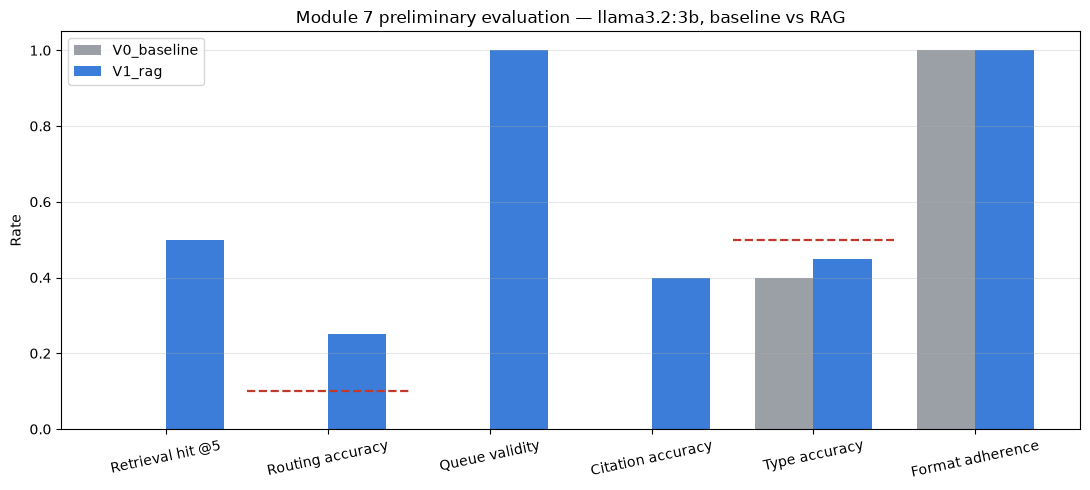

Saved: /Users/juampa/Documents/AtlantisUniversity/Master/MAI600/finalProject/images/evaluation_chart.png


In [16]:
# ============================================================
# 8D. Evaluation chart
# ============================================================

metrics = ["retrieval_hit_rate", "routing_accuracy", "queue_validity",
           "citation_accuracy", "type_accuracy", "format_adherence"]
labels  = [f"Retrieval hit @{TOP_K}", "Routing accuracy", "Queue validity",
           "Citation accuracy", "Type accuracy", "Format adherence"]

x = np.arange(len(metrics))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5))
colors = {"V0_baseline": "#9aa0a6", "V1_rag": "#3b7dd8"}
plotted = summary[summary["version"] != "V_majority_class"]
for i, (_, row) in enumerate(plotted.iterrows()):
    ax.bar(x + (i - 0.5) * width, [row[m] for m in metrics], width,
           label=row["version"], color=colors.get(row["version"]))

# The trivial reference is a line, not a bar: it is a floor to clear, not a system.
triv = summary[summary["version"] == "V_majority_class"].iloc[0]
for j, m in enumerate(metrics):
    if m in triv and pd.notna(triv[m]) and m != "queue_validity":
        ax.hlines(triv[m], j - 0.5, j + 0.5, color="#c0392b", linestyle="--", linewidth=1.6,
                  label="majority-class floor" if j == 0 else None)

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=12)
ax.set_ylim(0, 1.05); ax.set_ylabel("Rate")
ax.set_title(f"Module 7 preliminary evaluation — {MODEL}, baseline vs RAG")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGES / "evaluation_chart.png", dpi=150)
plt.show()
print("Saved:", IMAGES / "evaluation_chart.png")

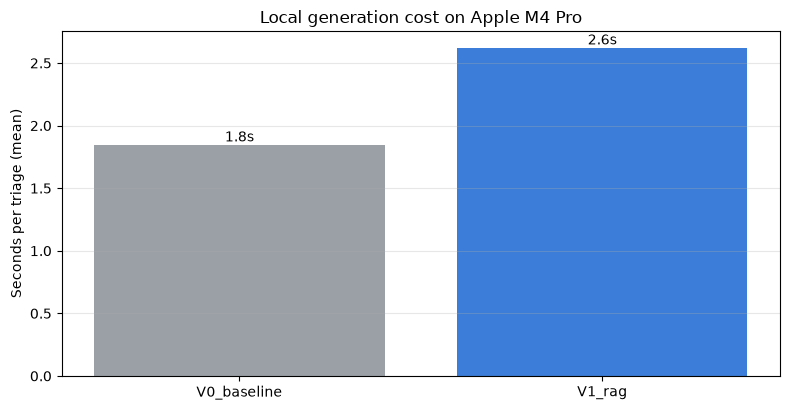

In [17]:
# ============================================================
# 8E. Response time chart
# ============================================================

rt = summary[summary["version"] != "V_majority_class"]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(rt["version"], rt["avg_response_time_s"], color=["#9aa0a6", "#3b7dd8"])
for i, v in enumerate(rt["avg_response_time_s"]):
    ax.text(i, v, f"{v:.1f}s", ha="center", va="bottom")
ax.set_ylabel("Seconds per triage (mean)")
ax.set_title("Local generation cost on Apple M4 Pro")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGES / "response_time_chart.png", dpi=150)
plt.show()

## 9. Pipeline diagram

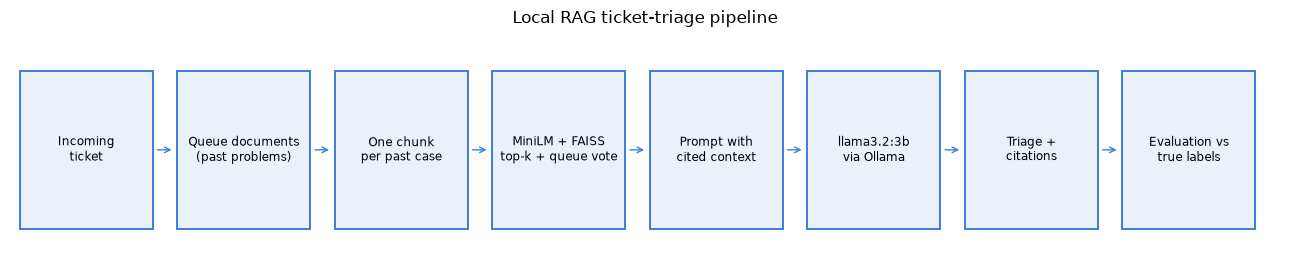

In [18]:
# ============================================================
# 9. Pipeline diagram
# ============================================================

fig, ax = plt.subplots(figsize=(13, 2.8))
ax.axis("off")

steps = ["Incoming\nticket", "Queue documents\n(past problems)", "One chunk\nper past case",
         "MiniLM + FAISS\ntop-k + queue vote", "Prompt with\ncited context", "llama3.2:3b\nvia Ollama",
         "Triage +\ncitations", "Evaluation vs\ntrue labels"]

for i, s in enumerate(steps):
    ax.add_patch(plt.Rectangle((i * 1.6, 0), 1.35, 1, facecolor="#eaf1fb",
                               edgecolor="#3b7dd8", linewidth=1.4))
    ax.text(i * 1.6 + 0.675, 0.5, s, ha="center", va="center", fontsize=8.5)
    if i < len(steps) - 1:
        ax.annotate("", xy=(i * 1.6 + 1.57, 0.5), xytext=(i * 1.6 + 1.37, 0.5),
                    arrowprops=dict(arrowstyle="->", color="#3b7dd8"))

ax.set_xlim(-0.1, len(steps) * 1.6); ax.set_ylim(-0.2, 1.2)
ax.set_title("Local RAG ticket-triage pipeline", pad=12)
plt.tight_layout()
plt.savefig(IMAGES / "pipeline_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Sample outputs (evidence)

In [19]:
# ============================================================
# 10. Side-by-side sample: baseline vs RAG
# ============================================================

tid = test_cases.loc[0, "test_id"]
case = ev[ev["test_id"] == tid]

print("=" * 78)
print("TICKET", tid)
print("=" * 78)
print(textwrap.fill(case.iloc[0]["question"][:600], 78))
print(f"\nTRUE LABELS -> queue: {case.iloc[0]['true_queue']} | "
      f"type: {case.iloc[0]['true_type']} | priority: {case.iloc[0]['true_priority']}")

for _, r in case.iterrows():
    print("\n" + "-" * 78)
    print(f"{r['version']}  ({r['model']}, {r['response_time_s']}s)")
    print("-" * 78)
    print(r["generated_answer"][:900])

TICKET T1
Excessive Billing Inquiry. There are unexpected charges on your monthly
invoice due to potential misconfigurations in your subscription settings. You
have already contacted support and reviewed the settings, but the issue still
exists.

TRUE LABELS -> queue: Billing and Payments | type: Incident | priority: medium

------------------------------------------------------------------------------
V0_baseline  (llama3.2:3b, 4.4s)
------------------------------------------------------------------------------
Queue: Excessive Billing Inquiry
Type: Problem
Priority: Medium
Citations: NONE
Draft response: 
Dear [Customer Name], 
We apologize for the unexpected charges on your recent invoice. 
Our team will review your subscription settings again to identify the cause of the issue and provide a resolution as soon as possible. 
We will be in touch with you shortly to discuss the next steps.

------------------------------------------------------------------------------
V1_rag  (llama3.2

## 11. Write the report drafts

In [20]:
# ============================================================
# 11. Generate methodology_draft.md and preliminary_results.md
# ============================================================

s = summary.set_index("version")
v0, v1, vt = s.loc["V0_baseline"], s.loc["V1_rag"], s.loc["V_majority_class"]

methodology = f"""# Methodology Draft

## Problem and approach

This project builds a local retrieval-augmented triage assistant for customer support
tickets. Given an incoming ticket, the system retrieves guidance from a knowledge base of
past resolutions and asks a small language model to propose a routing queue, a ticket
type, a priority, a draft first response, and citations. Everything runs on the analyst's
own laptop, because support tickets routinely contain customer names, phone numbers, and
account details that should not be sent to a hosted API.

## Data

The data is the public Customer IT Support ticket dataset (Kaggle, tobiasbueck / Open
Ticket AI), which is synthetic and carries no real customer information. The file holds
20,000 tickets in English and German. Only the English rows were kept, and rows missing a
subject, body, answer, queue, type, or priority were dropped, leaving {len(df):,} usable
tickets across {len(QUEUES)} support queues.

{len(test_cases)} tickets were held out as test cases, {CASES_PER_QUEUE} from every one of
the {len(QUEUES)} queues so that no queue is missing from the evaluation. The
remaining {len(kb_pool):,} tickets formed the pool used to build the knowledge base. The
split matters: if a test ticket's own answer sits in the corpus, the system retrieves
itself and every retrieval metric is meaningless.

## Knowledge base construction

Rather than indexing individual tickets, the corpus is {len(docs_df)} documents, one per
queue. Each document collects {CASES_PER_DOC} past cases from that queue, giving
{len(chunks_df)} chunks in total. This matches how a help desk actually stores knowledge,
and it makes citations legible: the model cites a named queue playbook instead of an
opaque ticket id.

Two choices here decide most of the retrieval quality.

**What gets embedded is the customer's problem, not the agent's answer.** A first version
indexed the resolution text and retrieved poorly. Agent answers are roughly half courtesy
boilerplate -- apologies, requests for a convenient time to call -- and once that is in the
vector, similarity is driven by the tone of a support email rather than by the problem.
Every incoming ticket sounds like a frustrated technical complaint, so it matched the
boilerplate of any queue equally well. In one case the top-ranked chunk, at a similarity
of 0.797, contained no topical content whatsoever. Matching problem text against problem
text keeps the comparison inside a single register. The resolution is still carried
alongside each chunk and shown to the model as payload, so it can ground the draft
response; it simply does not participate in the search.

**Each past case is its own chunk.** A fixed-width word window straddles case boundaries
and glues the tail of one problem onto the head of an unrelated one, producing chunks that
represent nothing in particular.

## Retrieval

Chunks were embedded with the `all-MiniLM-L6-v2` sentence-transformer (384 dimensions) and
indexed in FAISS using inner product over L2-normalised vectors, which is cosine
similarity. Each query retrieves the top {TOP_K} chunks. Dense embeddings were chosen over
TF-IDF because customers describe problems in their own words, so lexical overlap is a
weak signal for this task.

The retrieved chunks are then combined into a single queue prediction by a score-weighted
vote: similarities are summed per queue and the highest total wins. Reading only the
top-ranked chunk is noisy, because one strongly matching case can outrank a queue that
placed three moderate matches.

## Generation and local serving

Models are served locally through Ollama, which exposes an HTTP API at
`localhost:11434`. Prompts are sent with `requests.post()` to `/api/generate` at
temperature 0.2. The hardware is a MacBook Pro with an Apple M4 Pro chip and 48 GB of
unified memory. No GPU cloud runtime was used and no data left the machine.

Two system versions were compared on the same {len(test_cases)} test cases:

- **V0 (baseline)** — `{MODEL}` with no retrieval.
- **V1 (RAG)** — `{MODEL}` with the retrieved context.

The same model serves both, so retrieval is the only variable that changes between them.
Both receive an identical output-format instruction, so answers can be parsed and
scored the same way. The list of valid queue names is deliberately withheld from the
baseline prompt. Knowing which queues an organisation actually operates is precisely the
local knowledge retrieval is meant to supply, so giving it to the baseline for free would
conceal the effect under measurement.

## Evaluation

Scoring is automatic and runs against the dataset's own labels, so the numbers reproduce
on a re-run. Retrieval hit rate at 3 asks whether the correct queue document appeared
among the retrieved chunks. Routing accuracy compares the predicted queue with the true
one. Queue validity checks whether the predicted queue exists at all in the taxonomy,
which separates a wrong answer from an invented one. Citation accuracy checks that the
supporting document id appears in the model's citation field. Type and priority accuracy
are exact matches against the labels. Response time is wall-clock seconds per generation.

## Tools

Python 3.13, pandas, numpy, scikit-learn, sentence-transformers, faiss-cpu, matplotlib,
requests, Jupyter, and Ollama.
"""

(ROOT / "methodology_draft.md").write_text(methodology, encoding="utf-8")
print("methodology_draft.md written")

methodology_draft.md written


In [21]:
# ============================================================
# 11B. Preliminary results draft
# ============================================================

# The baseline occasionally lands on a real queue name by coincidence. Whether that
# happened is a property of the run, so this paragraph is written from the data rather
# than asserted in prose that a later run could contradict.
maj_type = test_cases["true_type"].value_counts().idxmax()

_bl = ev[(ev["version"] == "V0_baseline") & (ev["queue_valid"] == 1)]
if len(_bl):
    _hit = _bl.iloc[0]
    if _hit["routing_correct"]:
        _routed = "and routed it correctly"
    else:
        _routed = ("but the ticket actually belonged to " + str(_hit["true_queue"]) +
                   ", so even that syntactically valid answer was routed wrong")
    baseline_exception = (
        "The exception proves the point. In " + str(len(_bl)) + " of " +
        str(len(test_cases)) + " cases the baseline did land on a real queue name, " +
        str(_hit["pred_queue"]) + " -- the most generic label in the taxonomy and the "
        "most frequent one in the dataset -- " + _routed + ". It is a coincidence of "
        "vocabulary rather than knowledge of the taxonomy, and it does not recur "
        "reliably between runs.")
else:
    baseline_exception = (
        "Across repeated runs the baseline occasionally lands on a real queue name by "
        "coincidence, always Technical Support -- the most generic label in the taxonomy "
        "and the most frequent one in the dataset. It did not happen in this run. "
        "Nothing about it resembles knowledge of the taxonomy.")

best_route = summary.loc[summary["routing_accuracy"].idxmax(), "version"]

preliminary = f"""# Preliminary Results Draft

The prototype was tested on {len(test_cases)} held-out English tickets, {CASES_PER_QUEUE}
from each of the {len(QUEUES)} support queues. Each ticket was run through both system
versions, for {len(outputs_df)} generations in total. Both versions use `{MODEL}`, so any
difference between them comes from retrieval alone.

## Metric summary

| Metric | Majority class | V0 baseline | V1 RAG |
|---|---|---|---|
| Retrieval hit rate @{TOP_K} | n/a | n/a | {v1['retrieval_hit_rate']:.2f} |
| Correct queue wins the vote | n/a | n/a | {v1['vote_source_match']:.2f} |
| Routing accuracy | {vt['routing_accuracy']:.2f} | {v0['routing_accuracy']:.2f} | {v1['routing_accuracy']:.2f} |
| Queue validity | {vt['queue_validity']:.2f} | {v0['queue_validity']:.2f} | {v1['queue_validity']:.2f} |
| Citation accuracy | n/a | n/a | {v1['citation_accuracy']:.2f} |
| Type accuracy | {vt['type_accuracy']:.2f} | {v0['type_accuracy']:.2f} | {v1['type_accuracy']:.2f} |
| Priority accuracy | {vt['priority_accuracy']:.2f} | {v0['priority_accuracy']:.2f} | {v1['priority_accuracy']:.2f} |
| Format adherence | n/a | {v0['format_adherence']:.2f} | {v1['format_adherence']:.2f} |
| Mean response time | n/a | {v0['avg_response_time_s']:.1f}s | {v1['avg_response_time_s']:.1f}s |

The **majority class** column answers every ticket with the most frequent label and uses
no model at all. It is the floor any real system has to clear, and including it changes
how two of these rows should be read.

Per-test detail is in `results/evaluation_scores.csv`; the full generated text is in
`results/generated_outputs.csv`.

## The clearest effect: the baseline does not know the taxonomy exists

Queue validity separates being wrong from being ungrounded, and it is where the two
versions differ most: {v0['queue_validity']:.2f} for the baseline against
{v1['queue_validity']:.2f} with retrieval.

Without retrieval the model almost never picks a real queue. It does not appear to
understand that "queue" names a fixed routing destination at all, and instead invents a
title that summarises the ticket -- "Excessive Billing Inquiry", "Adobe Premiere Pro Crash
Investigation", "Digital Campaign Enhancement". These read well and a ticketing system
would reject every one of them. Retrieval supplies the ten queues that actually exist, and
the model stays inside them.

{baseline_exception}

This is worth stating carefully in the final article, because it is a better argument for
RAG than any accuracy delta. The knowledge the baseline is missing is not reasoning
ability; it is a fact about this organisation that no amount of model scale would supply.

## Only queue routing clears the floor

Read against the majority-class column, the three predicted fields separate sharply.

**Queue routing works.** {v1['routing_accuracy']:.2f} against a {vt['routing_accuracy']:.2f}
floor, with the baseline at {v0['routing_accuracy']:.2f}. This is the one field where the
system does something a trivial rule cannot.

**Type classification does not.** Both versions sit at or below the
{vt['type_accuracy']:.2f} floor. Answering "{maj_type}" to every ticket would score higher than either system. Retrieval does not change this:
an earlier version of the prompt withheld the retrieved cases' type labels entirely, and
adding them moved the score by nothing at all. The model is not reading the ticket for
type; it is following the shape of the label distribution, and slightly worse than a
constant would.

**Priority is marginal.** {v1['priority_accuracy']:.2f} against a
{vt['priority_accuracy']:.2f} floor is a difference of two tickets out of
{len(test_cases)}, which at this sample size is not evidence of anything.

Reporting only the first of these three would have been the easy path. The honest summary
is that this prototype is a queue router with two extra fields attached that currently do
no useful work.

## Where the routing ceiling is

The absolute number is modest and the reason is worth being honest about: several of these queues overlap semantically. "Technical Support",
"IT Support" and "Product Support" resolve similar problems in similar language, and the
errors cluster on exactly those boundaries.

Some of the ceiling belongs to the dataset rather than to the system. One test ticket
describes campaign data lost in HubSpot CRM through a SAP ERP integration, and is labelled
"Customer Service"; retrieval returned Product Support, Technical Support and Service
Outages. Reading the ticket, those look like better answers than the label. A human
triage team would not agree unanimously on these either, so exact-match accuracy against a
single gold label understates the system and overstates how well-defined the task is.

## Limitations

The test set is {len(test_cases)} tickets. That satisfies the assignment and shows
direction, but it is far too small for the difference between versions to be
statistically meaningful, and with {CASES_PER_QUEUE} tickets per queue a single error
moves a per-queue rate by a large margin.

The queue distribution in the source data is heavily skewed -- Technical Support carries
roughly twenty times the volume of General Inquiry -- while the queue documents are built
from equal-sized samples. Rare queues are therefore better represented in the knowledge
base than they are in reality, which flatters them.

Priority is the weakest label throughout, for both versions. Urgency depends on business
context that simply is not present in the ticket text, so neither the model nor a human
reading only the ticket could reliably recover it.

Citation accuracy is measured by a proxy: whether the expected document id appears in the
model's citation field. That checks the model cited the right source, not that the cited
source actually supports the sentence it is attached to. Real groundedness needs manual
review.

## Next steps

Hand-score groundedness on a subset instead of relying only on the citation proxy. Try
reranking the retrieved chunks before prompt assembly. Test whether merging the
overlapping support queues into coarser routing targets raises accuracy enough to justify
the loss of granularity, since that would test whether the errors are a system weakness or
a taxonomy artefact. Expand the test set well beyond {len(test_cases)} tickets.
"""

(ROOT / "preliminary_results.md").write_text(preliminary, encoding="utf-8")
print("preliminary_results.md written")

print("\n=== FILES WRITTEN ===")
for f in sorted(list(RESULTS.glob("*.csv")) + list(IMAGES.glob("*.png"))):
    print(" ", f.relative_to(ROOT), f"({f.stat().st_size/1024:.0f} KB)")

preliminary_results.md written

=== FILES WRITTEN ===
  images/evaluation_chart.png (44 KB)
  images/pipeline_diagram.png (38 KB)
  images/response_time_chart.png (26 KB)
  results/document_chunks.csv (114 KB)
  results/evaluation_scores.csv (5 KB)
  results/generated_outputs.csv (35 KB)
  results/preliminary_results_table.csv (4 KB)
  results/retrieved_chunks.csv (44 KB)
  results/summary_metrics.csv (0 KB)
